# BraTS 2020 — 2.5D U-Net + LSTM (MacOS Metal GPU)

**모델**: U-Net Encoder → ConvLSTM → U-Net Decoder  
**입력**: `(B, T, 4, H, W)` — T=8 연속 slice × 4 modality  
**출력**: `(B, T, 3, H, W)` — WT / TC / ET 마스크

## 0. 패키지 설치

In [1]:
import subprocess, sys

for pkg in ['nibabel', 'monai', 'segmentation-models-pytorch', 'scikit-learn']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✓ 패키지 설치 완료')

✓ 패키지 설치 완료


## 1. 임포트 및 GPU 설정

In [2]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

import nibabel as nib
from scipy.ndimage import zoom
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# 재현성
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device 설정
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print(f'✓ Device: mps (Metal GPU)')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f'✓ Device: cuda')
else:
    DEVICE = torch.device('cpu')
    print(f'Device: cpu')

print(f'PyTorch: {torch.__version__}')

✓ Device: mps (Metal GPU)
PyTorch: 2.12.0


## 2. 경로 및 하이퍼파라미터

In [3]:
# 데이터 경로 자동 탐색
candidates = [
    Path.home() / 'Desktop' / 'brats_work' / 'brats20-dataset-training-validation',
    Path.home() / 'Downloads' / 'brats20-dataset-training-validation',
    Path.cwd() / 'brats20-dataset-training-validation',
]

DATA_ROOT = None
for p in candidates:
    if p.exists():
        DATA_ROOT = p
        break

if DATA_ROOT is None:
    # 직접 경로 입력
    DATA_ROOT = Path('/Users/hong-igdaebaiohelseu/Desktop/brats_work/brats20-dataset-training-validation')

TRAIN_DATA_DIR = DATA_ROOT / 'BraTS2020_TrainingData' / 'MICCAI_BraTS2020_TrainingData'
print(f'데이터: {TRAIN_DATA_DIR}')
print(f'존재: {TRAIN_DATA_DIR.exists()}')

# 작업 디렉토리
WORK_DIR = Path.home() / 'brats_work'
PROCESSED_DIR = WORK_DIR / 'processed_lstm'
CKPT_DIR = WORK_DIR / 'checkpoints'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

# 하이퍼파라미터
T               = 8
STRIDE          = 4
IMG_SIZE        = 192
N_MODALITY      = 4
N_CLASSES       = 3
BRAIN_VOXEL_THR = 500
BATCH_SIZE      = 4
LR              = 3e-4
WEIGHT_DECAY    = 1e-5
N_EPOCHS        = 50
PATIENCE        = 10

print(f'배치: {BATCH_SIZE}, T: {T}, IMG: {IMG_SIZE}')

데이터: /Users/hong-igdaebaiohelseu/Desktop/brats_work/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
존재: True
배치: 4, T: 8, IMG: 192


## 3. 환자 목록 및 Split

In [4]:
def verify_patient(patient_dir: Path) -> bool:
    pid = patient_dir.name
    for mod in ['flair', 't1', 't1ce', 't2', 'seg']:
        if not (patient_dir / f'{pid}_{mod}.nii').exists():
            return False
    return True

all_patients   = sorted([d for d in TRAIN_DATA_DIR.iterdir() if d.is_dir()])
valid_patients = [p for p in all_patients if verify_patient(p)]

print(f'전체: {len(all_patients)}, 유효: {len(valid_patients)}')

patient_names = [p.name for p in valid_patients]
train_names, temp  = train_test_split(patient_names, test_size=0.3,   random_state=SEED)
val_names, test_names = train_test_split(temp,       test_size=0.667, random_state=SEED)

print(f'Train: {len(train_names)}, Val: {len(val_names)}, Test: {len(test_names)}')

split_df = pd.DataFrame({
    'patient': patient_names,
    'split': ['train' if n in train_names else ('val' if n in val_names else 'test')
              for n in patient_names]
})
split_df.to_csv(PROCESSED_DIR / 'patient_split.csv', index=False)
print('✓ split 저장 완료')

전체: 369, 유효: 368
Train: 257, Val: 36, Test: 75
✓ split 저장 완료


## 4. 전처리 함수

In [5]:
MODALITIES = ['flair', 't1ce', 't1', 't2']

def load_patient_volume(patient_dir):
    pid = patient_dir.name
    imgs = [nib.load(patient_dir / f'{pid}_{m}.nii').get_fdata(dtype=np.float32)
            for m in MODALITIES]
    image = np.stack(imgs, axis=-1)          # (H, W, D, 4)
    mask  = nib.load(patient_dir / f'{pid}_seg.nii').get_fdata(dtype=np.float32)
    return image, mask

def zscore_normalize(image):
    out = np.zeros_like(image)
    for c in range(image.shape[-1]):
        vol  = image[..., c]
        bmask = vol > 0
        if bmask.sum() == 0:
            continue
        out[..., c] = (vol - vol[bmask].mean()) / (vol[bmask].std() + 1e-8)
        out[..., c] *= bmask
    return out

def get_brain_bbox(image, margin=5):
    brain = image.sum(axis=-1) > 0
    rows  = np.any(brain, axis=(1, 2))
    cols  = np.any(brain, axis=(0, 2))
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    H, W = image.shape[:2]
    return (max(0, rmin-margin), min(H-1, rmax+margin),
            max(0, cmin-margin), min(W-1, cmax+margin))

def crop_and_resize(image, mask, bbox, size=192):
    r0, r1, c0, c1 = bbox
    ic = image[r0:r1+1, c0:c1+1, :, :]
    mc = mask [r0:r1+1, c0:c1+1, :]
    h, w = ic.shape[:2]
    sh, sw = size/h, size/w
    ir = np.zeros((size, size, ic.shape[2], N_MODALITY), dtype=np.float32)
    for c in range(N_MODALITY):
        ir[..., c] = zoom(ic[..., c], (sh, sw, 1), order=1)
    mr = zoom(mc, (sh, sw, 1), order=0)
    return ir, mr

def mask_to_regions(mask):
    wt = (mask > 0).astype(np.float32)
    tc = ((mask == 1) | (mask == 4)).astype(np.float32)
    et = (mask == 4).astype(np.float32)
    return np.stack([wt, tc, et], axis=-1)   # (H, W, D, 3)

def valid_slice(s, thr=500):
    return (s.sum(axis=-1) > 0).sum() >= thr

def generate_sequences(image, mask_regions, T=8, stride=4, thr=500):
    D, seqs = image.shape[2], []
    for s in range(0, D - T + 1, stride):
        isq = image       [:, :, s:s+T, :]     # (H, W, T, 4)
        msq = mask_regions[:, :, s:s+T, :]     # (H, W, T, 3)
        if not all(valid_slice(isq[:, :, t, :], thr) for t in range(T)):
            continue
        isq = isq.transpose(2, 0, 1, 3).copy()  # (T, H, W, 4)
        msq = msq.transpose(2, 0, 1, 3).copy()  # (T, H, W, 3)
        seqs.append({
            'image':     isq.astype(np.float32),
            'mask':      msq.astype(np.float32),
            'has_tumor': bool(msq.sum() > 0),
        })
    return seqs

print('✓ 전처리 함수 정의 완료')

✓ 전처리 함수 정의 완료


## 5. 전처리 실행 (최초 1회)

In [6]:
def preprocess_patient(pdir, split, out_root):
    pid     = pdir.name
    out_dir = out_root / split
    out_dir.mkdir(parents=True, exist_ok=True)
    if list(out_dir.glob(f'{pid}_seq*.npy')):
        return len(list(out_dir.glob(f'{pid}_seq*.npy'))), 0
    try:
        img, msk = load_patient_volume(pdir)
        img      = zscore_normalize(img)
        bbox     = get_brain_bbox(img)
        img, msk = crop_and_resize(img, msk, bbox, IMG_SIZE)
        regions  = mask_to_regions(msk)
        seqs     = generate_sequences(img, regions, T, STRIDE, BRAIN_VOXEL_THR)
        for i, seq in enumerate(seqs):
            np.save(out_dir / f'{pid}_seq{i:04d}.npy', seq, allow_pickle=True)
        return len(seqs), 0
    except Exception as e:
        print(f'[ERROR] {pid}: {e}')
        return 0, 1

pdir_map  = {p.name: p for p in valid_patients}
split_map = dict(zip(split_df['patient'], split_df['split']))
counts    = {'train': 0, 'val': 0, 'test': 0}
errors    = 0

for pid, sp in tqdm(split_map.items(), desc='전처리'):
    n, e = preprocess_patient(pdir_map[pid], sp, PROCESSED_DIR)
    counts[sp] += n
    errors     += e

print('\n✓ 전처리 완료')
for sp, n in counts.items():
    print(f'  {sp}: {n} sequences')
print(f'  오류: {errors}')

전처리: 100%|██████████| 368/368 [00:01<00:00, 218.34it/s]


✓ 전처리 완료
  train: 7237 sequences
  val: 981 sequences
  test: 2137 sequences
  오류: 0


## 6. Dataset & DataLoader

In [7]:
class BraTSDataset(Dataset):
    def __init__(self, proc_dir, split, oversample=0.7, augment=False):
        self.split     = split
        self.augment   = augment
        self.oversample = oversample
        files = sorted((proc_dir / split).glob('*.npy'))
        self.tumor_files = []
        self.other_files = []
        for f in files:
            d = np.load(f, allow_pickle=True).item()
            (self.tumor_files if d['has_tumor'] else self.other_files).append(f)
        self.all_files = files
        print(f'[{split}] {len(files)} seqs  종양:{len(self.tumor_files)}  비종양:{len(self.other_files)}')

    def __len__(self):
        return len(self.all_files)

    def __getitem__(self, idx):
        if self.split == 'train' and self.tumor_files:
            f = (random.choice(self.tumor_files)
                 if random.random() < self.oversample
                 else random.choice(self.other_files or self.tumor_files))
        else:
            f = self.all_files[idx]
        d     = np.load(f, allow_pickle=True).item()
        img   = d['image']   # (T, H, W, 4)
        mask  = d['mask']    # (T, H, W, 3)
        if self.augment:
            img, mask = self._aug(img, mask)
        # (T, H, W, C) → (T, C, H, W)
        img  = torch.from_numpy(img.copy()).permute(0, 3, 1, 2)
        mask = torch.from_numpy(mask.copy()).permute(0, 3, 1, 2)
        return img, mask

    def _aug(self, img, mask):
        if random.random() < 0.5:
            img  = img [:, :, ::-1, :].copy()
            mask = mask[:, :, ::-1, :].copy()
        if random.random() < 0.5:
            img  = img [:, ::-1, :, :].copy()
            mask = mask[:, ::-1, :, :].copy()
        if random.random() < 0.3:
            k    = random.choice([1, 2, 3])
            img  = np.rot90(img,  k, axes=(1, 2)).copy()
            mask = np.rot90(mask, k, axes=(1, 2)).copy()
        return img, mask

train_ds = BraTSDataset(PROCESSED_DIR, 'train', augment=True)
val_ds   = BraTSDataset(PROCESSED_DIR, 'val')
test_ds  = BraTSDataset(PROCESSED_DIR, 'test')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=1,          shuffle=False, num_workers=0)

imgs, masks = next(iter(train_loader))
print(f'\n배치 확인 — image: {imgs.shape}, mask: {masks.shape}')

[train] 7237 seqs  종양:4563  비종양:2674
[val] 981 seqs  종양:622  비종양:359
[test] 2137 seqs  종양:1321  비종양:816

배치 확인 — image: torch.Size([4, 8, 4, 192, 192]), mask: torch.Size([4, 8, 3, 192, 192])


## 7. 모델 정의

**MPS backward 버그 해결**: `BatchNorm2d` → `GroupNorm` 사용  
`GroupNorm(num_groups, num_channels)` — num_channels는 num_groups의 배수여야 함  
base=32 기준 채널: 32, 64, 128, 256, 512 → num_groups=8로 모두 나누어 떨어짐

In [8]:
NUM_GROUPS = 8   # GroupNorm num_groups (채널이 항상 8의 배수여야 함)

class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, hid_ch, ks=3):
        super().__init__()
        self.hid_ch = hid_ch
        self.conv   = nn.Conv2d(in_ch + hid_ch, 4 * hid_ch, ks, padding=ks//2, bias=True)

    def forward(self, x, h, c):
        i, f, g, o = self.conv(torch.cat([x, h], dim=1)).chunk(4, dim=1)
        i, f, o    = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o)
        g          = torch.tanh(g)
        c          = f * c + i * g
        h          = o * torch.tanh(c)
        return h, c

    def init_hidden(self, B, H, W, device):
        z = torch.zeros(B, self.hid_ch, H, W, device=device)
        return z, z.clone()


class ConvLSTM(nn.Module):
    def __init__(self, in_ch, hid_ch, ks=3):
        super().__init__()
        self.cell = ConvLSTMCell(in_ch, hid_ch, ks)

    def forward(self, x):            # x: (B, T, C, H, W)
        B, T, C, H, W = x.shape
        h, c = self.cell.init_hidden(B, H, W, x.device)
        out  = []
        for t in range(T):
            h, c = self.cell(x[:, t], h, c)
            out.append(h)
        return torch.stack(out, dim=1)  # (B, T, hid_ch, H, W)


class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        # GroupNorm(num_groups, num_channels) — num_channels must be divisible by num_groups
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.GroupNorm(NUM_GROUPS, out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.GroupNorm(NUM_GROUPS, out_c),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)


class Down(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_c, out_c))
    def forward(self, x):
        return self.net(x)


class Up(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = DoubleConv(in_c, out_c)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=True)
        return self.conv(torch.cat([skip, x], dim=1))


class UNetEncoder(nn.Module):
    def __init__(self, in_c=4, base=32):
        super().__init__()
        self.e1  = DoubleConv(in_c,    base)      # 32
        self.e2  = Down(base,    base*2)           # 64
        self.e3  = Down(base*2,  base*4)           # 128
        self.e4  = Down(base*4,  base*8)           # 256
        self.bot = Down(base*8,  base*16)          # 512
    def forward(self, x):
        s1 = self.e1(x)
        s2 = self.e2(s1)
        s3 = self.e3(s2)
        s4 = self.e4(s3)
        b  = self.bot(s4)
        return [s1, s2, s3, s4], b


class UNetDecoder(nn.Module):
    def __init__(self, n_cls=3, base=32):
        super().__init__()
        self.u4   = Up(base*16 + base*8, base*8)
        self.u3   = Up(base*8  + base*4, base*4)
        self.u2   = Up(base*4  + base*2, base*2)
        self.u1   = Up(base*2  + base,   base)
        self.head = nn.Conv2d(base, n_cls, 1)
    def forward(self, bot, skips):
        s1, s2, s3, s4 = skips
        x = self.u4(bot, s4)
        x = self.u3(x,   s3)
        x = self.u2(x,   s2)
        x = self.u1(x,   s1)
        return self.head(x)


class UNetLSTM(nn.Module):
    def __init__(self, in_ch=4, n_cls=3, base=32):
        super().__init__()
        self.encoder = UNetEncoder(in_ch, base)
        self.decoder = UNetDecoder(n_cls, base)
        self.lstm    = ConvLSTM(base*16, base*16)

    def forward(self, x):                     # (B, T, 4, H, W)
        B, T, C, H, W = x.shape

        # 1. Encoder: 각 slice 독립 처리
        xf              = x.reshape(B*T, C, H, W)
        skips_flat, bot = self.encoder(xf)    # bot: (B*T, 512, h, w)

        # 2. ConvLSTM: 시간 맥락 통합
        _, bC, bH, bW = bot.shape
        lstm_out = self.lstm(bot.reshape(B, T, bC, bH, bW))  # (B, T, 512, h, w)

        # 3. Decoder: skip은 (B*T, ...) 그대로 사용
        logits = self.decoder(
            lstm_out.reshape(B*T, bC, bH, bW),
            skips_flat
        )                                     # (B*T, 3, H, W)

        return logits.reshape(B, T, N_CLASSES, H, W)


# 모델 초기화
model = UNetLSTM(in_ch=N_MODALITY, n_cls=N_CLASSES, base=32).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f'파라미터: {n_params:,}')

# 더미 forward 확인
with torch.no_grad():
    dummy = torch.randn(2, T, N_MODALITY, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out   = model(dummy)
    print(f'입력: {tuple(dummy.shape)} → 출력: {tuple(out.shape)}')
del dummy, out

파라미터: 26,726,371
입력: (2, 8, 4, 192, 192) → 출력: (2, 8, 3, 192, 192)


## 8. Loss & Metrics

In [9]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred  = torch.sigmoid(pred)
        dims  = tuple(range(2, pred.ndim))
        inter = (pred * target).sum(dim=dims)
        dice  = (2*inter + self.smooth) / (pred.sum(dim=dims) + target.sum(dim=dims) + self.smooth)
        return 1 - dice.mean()


class DiceBCELoss(nn.Module):
    def __init__(self, dw=0.5, bw=0.5):
        super().__init__()
        self.dice = DiceLoss()
        self.bce  = nn.BCEWithLogitsLoss()
        self.dw, self.bw = dw, bw

    def forward(self, pred, target):
        return self.dw * self.dice(pred, target) + self.bw * self.bce(pred, target)


@torch.no_grad()
def dice_scores(logits, target, thr=0.5):
    """logits, target을 cpu float로 받아서 계산"""
    pred   = (torch.sigmoid(logits) > thr).float()
    smooth = 1e-6
    if pred.ndim == 5:
        B, T, C, H, W = pred.shape
        pred   = pred.reshape(B*T, C, H, W)
        target = target.reshape(B*T, C, H, W)
    scores = {}
    for i, name in enumerate(['WT', 'TC', 'ET']):
        p = pred[:, i].reshape(-1)
        t = target[:, i].reshape(-1)
        scores[name] = ((2*(p*t).sum() + smooth) / (p.sum() + t.sum() + smooth)).item()
    scores['mean'] = float(np.mean(list(scores.values())))
    return scores


criterion = DiceBCELoss()
print('✓ Loss / Metric 정의 완료')

✓ Loss / Metric 정의 완료


## 9. 학습

In [10]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, all_scores = 0.0, []
    for imgs, masks in tqdm(loader, desc='Train', leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        # dice는 cpu에서 계산 (MPS 안전)
        all_scores.append(dice_scores(logits.detach().cpu().float(),
                                      masks.cpu().float()))
    avg_loss = total_loss / len(loader)
    avg_dice = {k: np.mean([s[k] for s in all_scores]) for k in all_scores[0]}
    return avg_loss, avg_dice


@torch.no_grad()
def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, all_scores = 0.0, []
    for imgs, masks in tqdm(loader, desc='Val  ', leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        total_loss += criterion(logits, masks).item()
        all_scores.append(dice_scores(logits.cpu().float(), masks.cpu().float()))
    avg_loss = total_loss / len(loader)
    avg_dice = {k: np.mean([s[k] for s in all_scores]) for k in all_scores[0]}
    return avg_loss, avg_dice


best_dice    = 0.0
patience_cnt = 0
history      = []

print(f'학습 시작 ({N_EPOCHS} epochs, patience={PATIENCE})')
print('='*72)

for epoch in range(1, N_EPOCHS + 1):
    tr_loss, tr_dice = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    va_loss, va_dice = val_epoch(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history.append({
        'epoch': epoch,
        'train_loss': tr_loss, 'val_loss': va_loss,
        'train_dice': tr_dice['mean'],
        'val_WT': va_dice['WT'], 'val_TC': va_dice['TC'],
        'val_ET': va_dice['ET'], 'val_mean': va_dice['mean'],
    })

    flag = ''
    if va_dice['mean'] > best_dice:
        best_dice    = va_dice['mean']
        patience_cnt = 0
        torch.save(model.state_dict(), CKPT_DIR / 'best.pth')
        flag = ' ★'
    else:
        patience_cnt += 1

    print(f'Ep{epoch:3d} | tr={tr_loss:.4f} va={va_loss:.4f} '
          f'| WT={va_dice["WT"]:.4f} TC={va_dice["TC"]:.4f} ET={va_dice["ET"]:.4f}'
          f' mean={va_dice["mean"]:.4f}{flag}')

    if patience_cnt >= PATIENCE:
        print(f'Early stopping (epoch {epoch})')
        break

print(f'\nBest Val Dice: {best_dice:.4f}')

학습 시작 (50 epochs, patience=10)


Ep  1 | tr=0.3820 va=0.3090 | WT=0.5415 TC=0.5686 ET=0.6400 mean=0.5834 ★


Ep  2 | tr=0.2709 va=0.2952 | WT=0.5612 TC=0.7337 ET=0.7650 mean=0.6866 ★


Ep  3 | tr=0.2664 va=0.2916 | WT=0.5793 TC=0.7138 ET=0.7102 mean=0.6678


Ep  4 | tr=0.2560 va=0.2905 | WT=0.5683 TC=0.6855 ET=0.6856 mean=0.6465


...

Ep 24 | tr=0.2402 va=0.2828 | WT=0.5898 TC=0.7417 ET=0.7421 mean=0.6912


Ep 25 | tr=0.2422 va=0.2828 | WT=0.5769 TC=0.7460 ET=0.7464 mean=0.6898


Ep 26 | tr=0.2407 va=0.2850 | WT=0.5790 TC=0.7282 ET=0.7422 mean=0.6831


Ep 27 | tr=0.2394 va=0.2823 | WT=0.5746 TC=0.7184 ET=0.7276 mean=0.6735


Ep 28 | tr=0.2364 va=0.2834 | WT=0.5964 TC=0.7748 ET=0.7842 mean=0.7185
Early stopping (epoch 28)

Best Val Dice: 0.7310


## 10. 학습 곡선

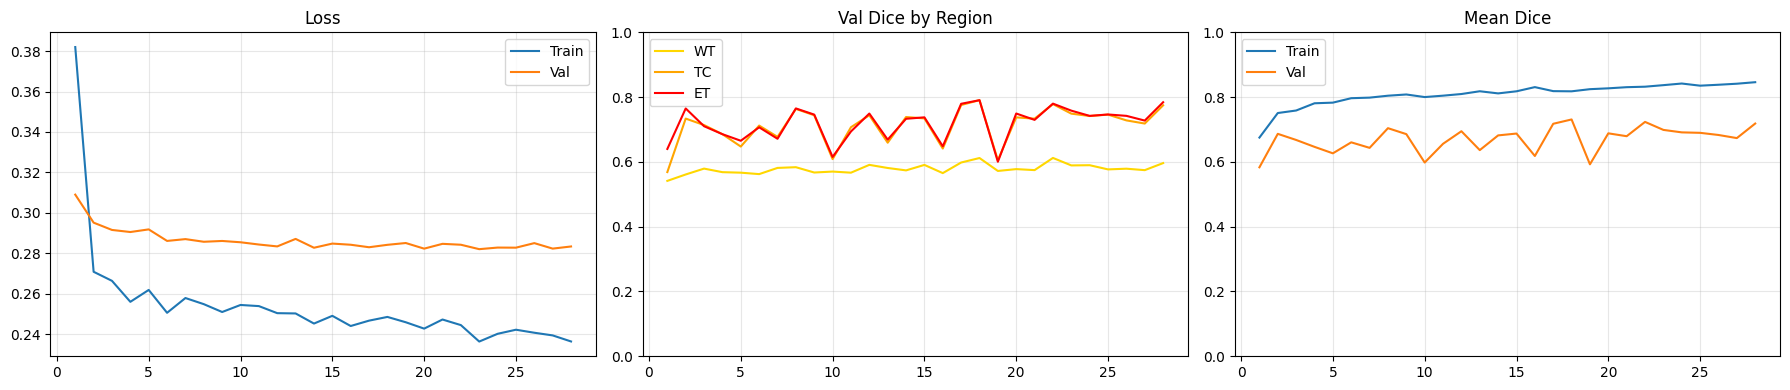

In [11]:
hist = pd.DataFrame(history)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(hist['epoch'], hist['train_loss'], label='Train')
axes[0].plot(hist['epoch'], hist['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist['epoch'], hist['val_WT'],   label='WT', color='gold')
axes[1].plot(hist['epoch'], hist['val_TC'],   label='TC', color='orange')
axes[1].plot(hist['epoch'], hist['val_ET'],   label='ET', color='red')
axes[1].set_title('Val Dice by Region'); axes[1].set_ylim(0,1)
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(hist['epoch'], hist['train_dice'], label='Train')
axes[2].plot(hist['epoch'], hist['val_mean'],   label='Val')
axes[2].set_title('Mean Dice'); axes[2].set_ylim(0,1)
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(WORK_DIR / 'curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Test 평가

In [12]:
model.load_state_dict(torch.load(CKPT_DIR / 'best.pth', map_location=DEVICE))
model.eval()

test_scores = []
with torch.no_grad():
    for imgs, masks in tqdm(test_loader, desc='Test'):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        logits = model(imgs)
        test_scores.append(dice_scores(logits.cpu().float(), masks.cpu().float()))

res = {k: np.mean([s[k] for s in test_scores]) for k in test_scores[0]}

print('='*40)
print('  Test Results')
print('='*40)
print(f'  WT : {res["WT"]:.4f}')
print(f'  TC : {res["TC"]:.4f}')
print(f'  ET : {res["ET"]:.4f}')
print(f'  Mean: {res["mean"]:.4f}')
print('='*40)

# 결과 저장
row = {'model':'UNet+LSTM', 'T':T,
       'WT':round(res['WT'],4), 'TC':round(res['TC'],4),
       'ET':round(res['ET'],4), 'mean':round(res['mean'],4)}
path = WORK_DIR / 'metrics.csv'
df   = pd.read_csv(path) if path.exists() else pd.DataFrame()
pd.concat([df, pd.DataFrame([row])], ignore_index=True).to_csv(path, index=False)
hist.to_csv(WORK_DIR / 'history.csv', index=False)
print(f'\n✓ 저장 완료: {WORK_DIR}')

Test: 100%|██████████| 2137/2137 [02:34<00:00, 13.81it/s]

  Test Results
  WT : 0.5897
  TC : 0.8405
  ET : 0.8361
  Mean: 0.7554

✓ 저장 완료: /Users/hong-igdaebaiohelseu/brats_work
